In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pdb
from IPython.display import display
import os

In [2]:
import ee
import geemap
service_account = ' boba-account@boba-430314.iam.gserviceaccount.com '
credentials = ee.ServiceAccountCredentials(service_account,'C:/Users/arj26323/OneDrive - University of Georgia/Documents/GEE AUTH/boba-430314-a19be859bfca.json')

ee.Initialize(credentials)

print(geemap.__version__)

0.34.1


C:\Users\arj26323\.conda\envs\geeml\lib\site-packages\matplotlib_scalebar\scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


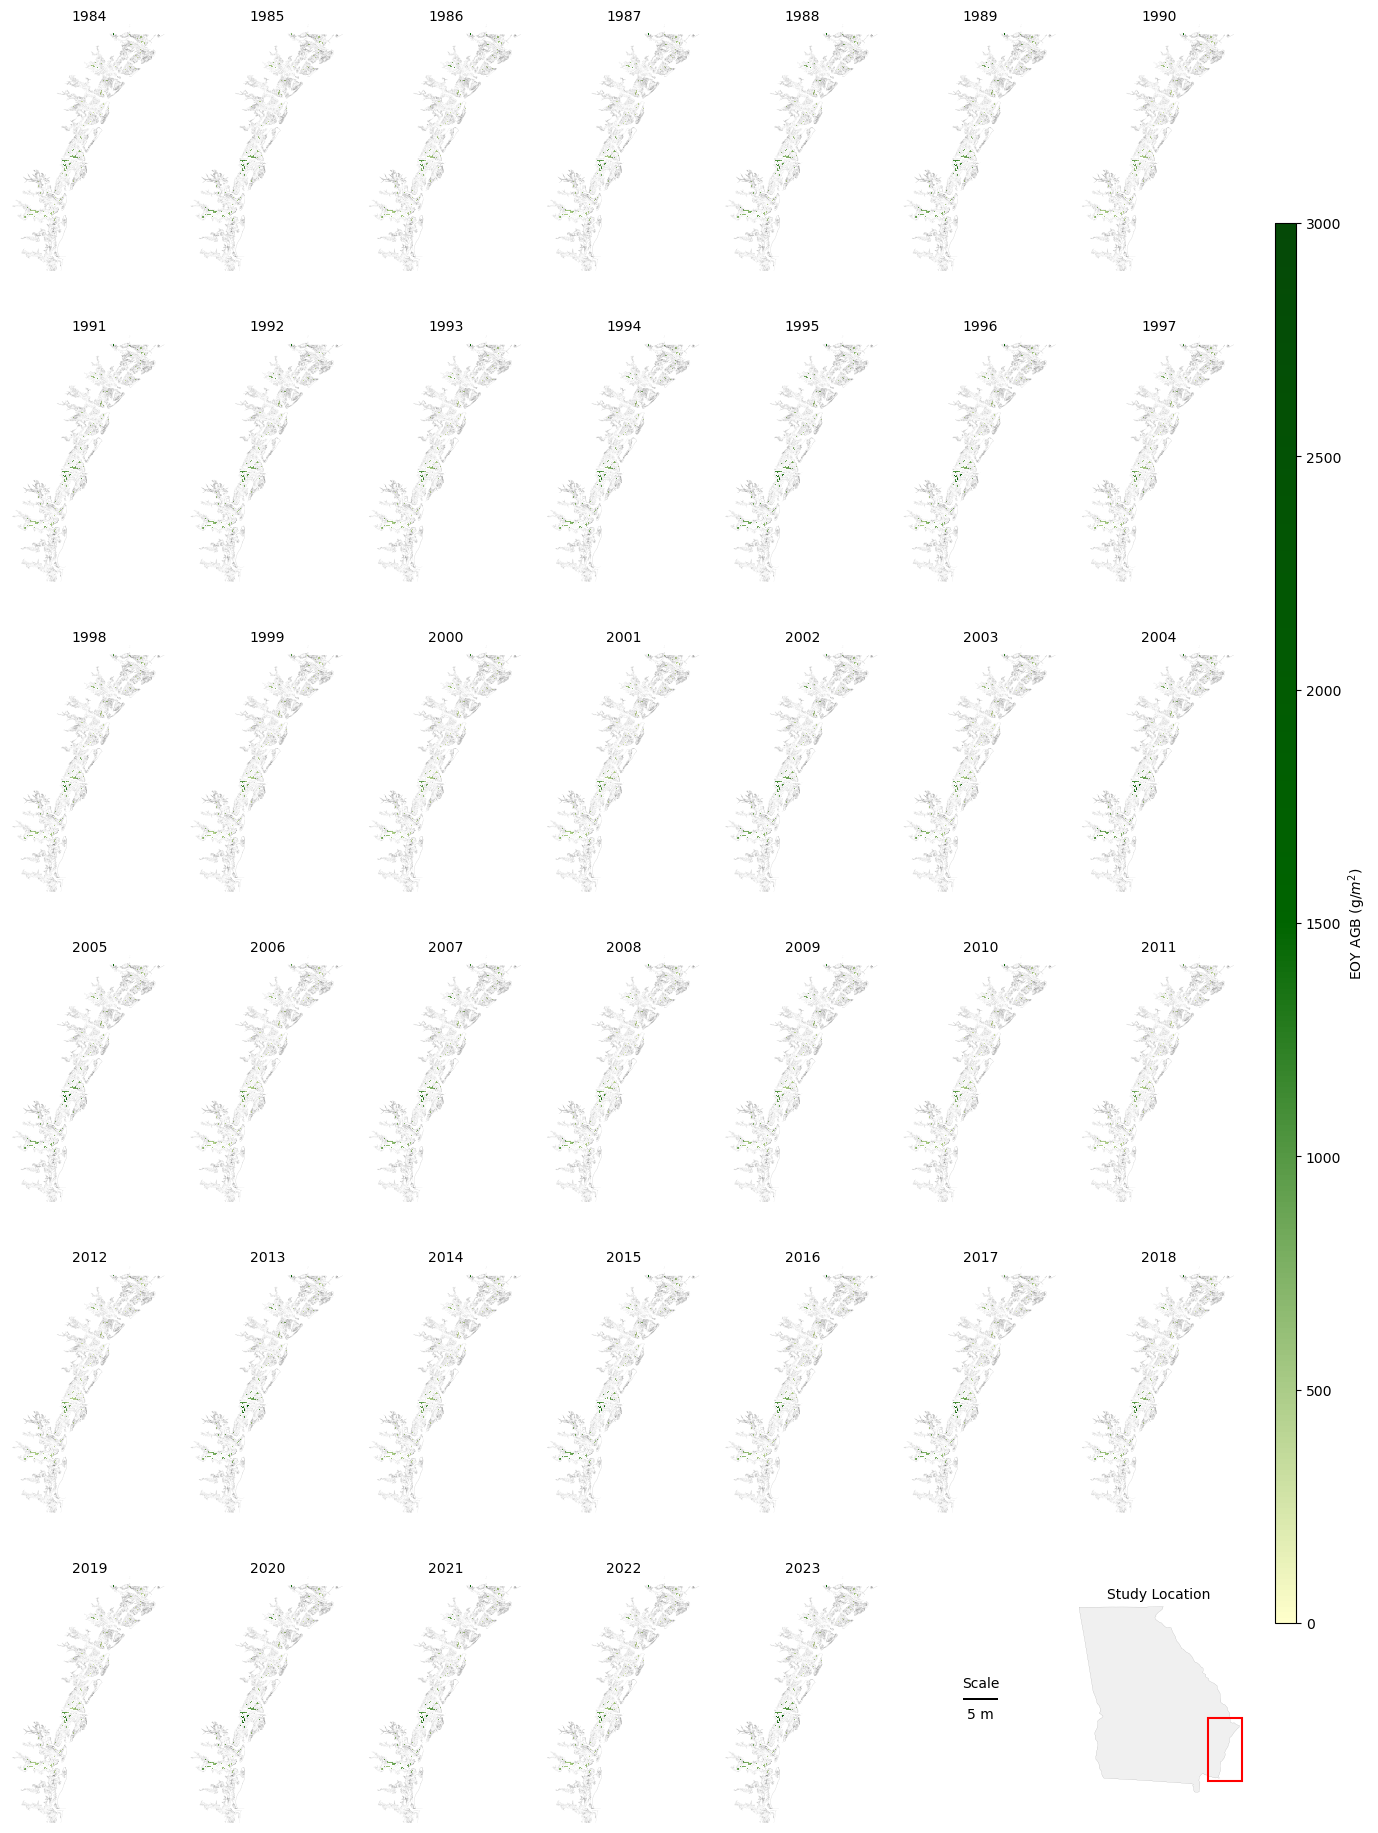

In [17]:
##AGB panel map

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.plot import show
from rasterio.transform import rowcol
import glob
import os
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as patches
from matplotlib_scalebar.scalebar import ScaleBar
from geopy.distance import great_circle

# 1. Get all your 40 GeoTIFFs (adjust the path/pattern to match your files)
tiff_dir = "F:/Biomass tiffs/Biomass modeling/Georgia/Georgia model only/LOGO_final/"
# Sorting ensures Year 1 comes before Year 2, etc.
tiff_files = sorted(glob.glob(os.path.join(tiff_dir, "*.tif"))) 

# Load your shapefile background/overlay
base_shape = "F:/Wetlands shapefiles/GA_shapefile_wetlands/GA_estuaries.shp"
gdf = gpd.read_file(base_shape)

ga_gdf = gpd.read_file("F:/US states/Georgia.shp")

# 2. Define grid dimensions
nrows = 6
ncols = 7

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 20), sharex=True, sharey=True)
axes_flat = axes.flatten() # Flatten to loop easily from 0 to 39

# Define your custom colormap
positions = [0, 0.5, 1]
colors = ["#FFFFCB", "#006400", "#054907"]
custom_cmap = LinearSegmentedColormap.from_list("brown_to_green", list(zip(positions, colors)), N=256)


# Variables to store bounds for our inset box later
raster_bounds = None
raster_crs = None

# --- Loop Through 40 Years ---
for i in range(40):
    if i >= len(tiff_files):
        break
        
    ax = axes_flat[i]
    tiff_path = tiff_files[i]
    
    # Extract Year Label
    file_name = os.path.basename(tiff_path)
    year_label = "".join(filter(str.isdigit, file_name))
    
    with rasterio.open(tiff_path) as src:
        # Capture spatial info from the first raster for our inset map zoom reference
        if i == 0:
            raster_bounds = src.bounds
            raster_crs = src.crs
            # Ensure the state shapefile matches raster projection
            
            ##Transforming pixels and scale
            pixel_size_in_degrees = src.transform[0]
            center_lat = (raster_bounds.bottom + raster_bounds.top) / 2
            center_lon = (raster_bounds.left + raster_bounds.right) / 2
            point_a = (center_lat, center_lon)
            point_b = (center_lat, center_lon + 1.0)
            meters_per_degree = great_circle(point_a, point_b).meters
            pixel_size_in_meters = pixel_size_in_degrees * meters_per_degree            
            
            ga_gdf = ga_gdf.to_crs(raster_crs)
            gdf = gdf.to_crs(raster_crs)
        
        # Plot raster
        show(src, ax=ax, cmap=custom_cmap, vmin=0, vmax=3000, zorder = 1)
        
    # Plot shapefile overlay
    gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.01, zorder = 2)
    
    # --- FIX 1: Zoom strictly into the Raster Extent ---
    # This overrides the "small blob" issue by forcing matplotlib to focus exactly on the raster data boundaries
    ax.set_xlim(raster_bounds.left, raster_bounds.right)
    ax.set_ylim(raster_bounds.bottom, raster_bounds.top)
    
    # FORCE SUBPLOT BOX TO SHRINK TO MAP SHAPE
    ax.set_aspect('equal', adjustable='box')
    
    # Style panel
    ax.set_title(year_label if year_label else f"Year {i+1}", fontsize=10, pad=2)
    ax.axis('off')

# --- FIX 2: Handle Blank Space & Inset Map ---
# Panels 40 and 41 (the 41st and 42nd slots) are empty. 
# We turn off panel 40 entirely, and use panel 41 as the host for the Georgia locator map.
# axes_flat[40].axis('off') 
ax_scale = axes_flat[40] # Use the 41st slot for the scale bar
ax_scale.axis('off')

scalebar = ScaleBar(dx=pixel_size_in_meters, units="m", dimension="si-length",
                    location="center", label="Scale", box_alpha=0.0)

# Add it to the empty axis slot
ax_scale.add_artist(scalebar)

ax_inset_host = axes_flat[41]
ax_inset_host.axis('off') # Clean host background

# Create the inset directly over the empty panel slot space
# Making it width/height "100%" fills the empty panel slot perfectly
ax_inset = inset_axes(ax_inset_host, width="100%", height="100%", loc='center')

# Plot Georgia State boundary
ga_gdf.plot(ax=ax_inset, facecolor='#f0f0f0', edgecolor='black', linewidth=0.05)

# Build "You Are Here" red rectangle using coordinates from our raster bounds
if raster_bounds:
    left, bottom, right, top = raster_bounds
    rect = patches.Rectangle((left, bottom), right - left, top - bottom, 
                             linewidth=1.5, edgecolor='red', facecolor='none', zorder=10)
    ax_inset.add_patch(rect)

# Polish the inset map
ax_inset.set_xticks([])
ax_inset.set_yticks([])
for spine in ax_inset.spines.values():
    spine.set_visible(False)
ax_inset.set_title("Study Location", fontsize=10, y=0.95)

# --- Global Colorbar ---
im = axes_flat[0].get_images()[0]
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7]) # Adjust right margin positioning
fig.colorbar(im, cax=cbar_ax, label='EOY AGB (g/$m^2$)')

plt.subplots_adjust(right=0.91, left=0.02, bottom=0.05, top=0.95, wspace=0.01, hspace=0.25)

##Save at high res
import os
output_dir = r'F:\Figures_PaperII'
file_name = 'AGB_40yrs_XYZ_test.tif'

save_path = os.path.join(output_dir, file_name)

# plt.savefig(save_path, bbox_inches='tight', dpi=1000)

plt.show()

In [ ]:
#Finito

raster_crs